In [5]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [18]:
files = Path("out_shap").glob("shap_global_*.csv")

rows = {}
for f in files:
    name = f.stem.replace("shap_global_", "")
    df = pd.read_csv(f)
    rows[name] = pd.Series(df["mean_abs_shap"].values, index=df["feature"])

importance_df = pd.DataFrame(rows).T
importance_df = importance_df.fillna(0.0)
print(importance_df)
# optional: normalize each model row so they’re comparable
importance_norm = importance_df.div(importance_df.sum(axis=1), axis=0)
print(importance_norm)

feature           last_y  lag_1_t0  lag_4_t0  lag_8_t0  lag_24_t0  lag_96_t0  \
LigthGBM_model  1.704441  1.411624  1.328002  1.141790   0.737938  16.836153   
XGB_model       1.693193  1.084858  1.177016  1.110292   0.418905  14.556959   

feature         lag_192_t0  lag_672_t0  ramp_1h_t0  ramp_6h_t0  ...  \
LigthGBM_model    4.468458   12.427774    0.742538    0.923128  ...   
XGB_model         3.487848    7.998701    0.364173    0.583301  ...   

feature         hod_target  dow_target  month_target  is_weekend_target  \
LigthGBM_model    0.235354    4.701546      1.727858           0.787653   
XGB_model         0.209296    5.203426      1.152908           1.082509   

feature         load_fc_target  load_ramp_1h_target  load_ramp_6h_target  \
LigthGBM_model       15.806009             1.929365             3.289640   
XGB_model            11.130083             1.748857             3.547153   

feature         load_day_mean  load_day_max  load_day_min  
LigthGBM_model       1.386717 

In [14]:
def plot_heatmap(df, title, top_k=25):

    # pick most important features overall
    top_features = df.mean(axis=0).sort_values(ascending=False).head(top_k).index
    
    plot_df = df[top_features].T  # features = rows, models = columns

    fig, ax = plt.subplots(figsize=(0.8 * plot_df.shape[1] + 3,
                                    0.4 * plot_df.shape[0] + 3))

    im = ax.imshow(plot_df.values, aspect="auto")

    ax.set_title(title)

    # X axis = models
    ax.set_xticks(np.arange(plot_df.shape[1]))
    ax.set_xticklabels(plot_df.columns, rotation=45, ha="left")

    # Move model names to the TOP
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # Y axis = features
    ax.set_yticks(np.arange(plot_df.shape[0]))
    ax.set_yticklabels(plot_df.index)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("mean(|SHAP|)")

    plt.tight_layout()
    plt.show()

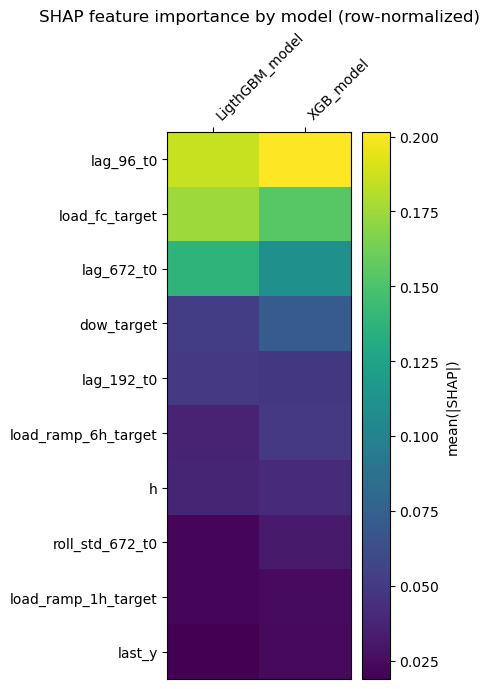

In [16]:
plot_heatmap(importance_norm, "SHAP feature importance by model (row-normalized)", top_k=10)